In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


머신러닝이란, 실생활/새로운 환경에서 얻어지는 지식을 통해 기계가 발전할 수 있는 것을 의미한다. 

- Tom michell이 말하는 머신러닝의 정의: "If its performance at tasks in T, as measured by P, improves with experience E." : 어떤 일이 있고 계속된 경험을 통해서 improve해 평가가 더 나아지게하는 것이 머신러닝이다. (이때문에 딥러닝(DL)이 머신러닝 안에 속함. AI > ML > DL)

머신러닝의 학습 방법은 크게 **지도학습(Supervised learning)** 과 **비지도학습(Unsupervised learning)** 그리고 **강화학습(Reinforcement)** 으로 나눌 수 있다.  

#### 지도학습(Supervised learning)
- 분류(Classification): 정해진 범주(클래스) 중 하나를 예측

    ex. KNN, Decision Tree, Logistic Regression, SVM

- 회귀(Regression): 연속적인 수치를 예측

    ex. Linear regression, polynomial regression, KNN

#### 비지도학습(Unsupervised learning)
- 군집화(Clustering): 정답 라벨 없이 비슷한 데이터끼리 묶기

### 강화학습(Reinforcement)
- Environment, Agent, state, action, reward로 구성되어있으며, 에이전트가 최적의 결과를 얻어낼 수 있도록 경험을 통해 보상을 받으며 학습함. 
<br>
<div style="text-align: center;">
    <img src="https://blog.kakaocdn.net/dna/LlQxT/btqFvu1JBMs/AAAAAAAAAAAAAAAAAAAAAAZkxScgbwPTpzbuUMwH4y4QiJXfy4wtbrbtR2m3xkBj/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1774969199&allow_ip=&allow_referer=&signature=N5VpBA5ZbLhPMOpVNFrYYGBttH0%3D" width="500"/>
</div>

해당 파트에선 지도학습의 대표적인 알고리즘인 로지스틱 회귀(Logistic regression), KNN, SVM에 대해 다룰 예정이다. 

## 로지스틱 회귀(Logistic regression)


로지스틱 회귀(Logistic regression)는 이름에 "회귀"가 들어가지만, 실제로는 **분류(Classification)** 문제에서 널리 사용된다. 대표적인 예시는 메일이 스팸인지 아닌지 분류하는 **이진 분류(Binary classification)** 이다.


## 1. 이진 분류 (Binary Classification)


로지스틱 회귀(Logistic Regression)에서 가설 함수(hypothesis function)은 다음과 같은 선형 함수 형태를 가진다.

$$h(x) = w^T x + b$$


하지만 이진 분류 문제에서는 이러한 선형 함수가 그대로 사용되기 어렵다. 그 이유는 선형 함수의 출력값 범위가 $(-\infty, \infty)$ 이기 때문에 확률 값(0~1)으로 해석할 수 없기 때문이다.
<br>
예를 들어 결과가
- 3.2
- -5.7

같이 나오면 클래스에 속할 확률로 해석할 수 없다.


## 시그모이드 함수(Sigmoid Function)

따라서 이진 분류 문제에서는 선형식의 결과를 0과 1 사이 값으로 변환하는 함수가 필요하다.
그래서 분류 문제에서는 선형식의 결과를 **시그모이드 함수(Sigmoid function)** 에 통과시켜 $0\sim1$ 사이 값으로 변환한다.



$$ \mathrm g(z) = 1/(1+e^{-z}), z = \theta^{T}x$$

$$h_{\theta}(x) = \frac{1}{1+e^{-\theta^{T}x}} $$
<br>
<div align="center">
<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*muc-SoWYkLHKdsTGFiygxA.png" width="500"/>
</div>

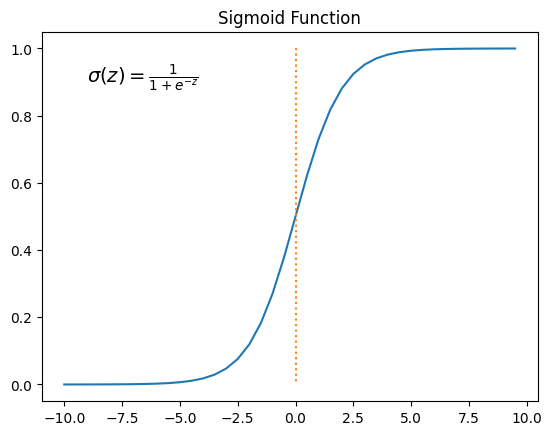

In [49]:
#sigmoid함수를 직접 작성해보자.
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.arange(-10.0, 10.0, 0.5)
y = sigmoid(x)

plt.plot(x, y)
plt.plot([0,0], [1.0,0.0], ':')

plt.title('Sigmoid Function')

# 수식 출력
plt.text(-9, 0.9, r'$\sigma(z) = \frac{1}{1 + e^{-z}}$', fontsize=14)

plt.show()

위 그래프를 통해 x>0인 경우 x값이 커질수록 1에 가까워지며 x<0인 경우 x값이 작아질수록 0에 수렴한다는 사실을 확인 가능하다.

##  손실 함수(Cost/Loss/Object function)


우리의 목표는, 모델이 예측한 값과 실제값의 차이가 최소화되는 것이다. 따라서 이 차이를 수치로 계산하는 함수가 필요한데 이를 손실함수(Cost function)라 부른다. (이때 Cost, Loss, Object function이라 불리는데 다 같은 손실함수를 칭한다.)

실제 값이 1인 경우에 예측 값(h(x))이 1과 가까우면 비용이 작고, 예측 값이 0에 가까우면 비용이 매우 크다는 사실을 안다. 이를 바탕으로 손실 함수(cost function) 중 **이진 크로스 엔트로피 함수(BCE, Binary Cross Entropy Loss)** 를 작성하면 다음과 같다.
  
  $$Cost(h_{\theta}(x), y) = \begin{cases} -\log(h_{\theta}(x)) \qquad \; \,  (y=1)\\ -\log(1-h_{\theta}(x)) \quad (y=0)\\ \end{cases}$$
<br>
  이 식을 하나로 통일하고, 오차의 평균을 손실함수로 정의하면 다음과 같다.
  
  $$Cost(h_{\theta}(x), y) = -\frac{1}{n}\sum_{i=1}^{n}[y^{(i)}logH(x^{(i)}) + (1 - y^{(i)})log(1 - H(x^{(i)}))]$$
  $$L(y,p) = -\left(y \log p + (1-y)\log(1-p)\right)$$

      - 𝑦 : 실제 라벨 (0 또는 1)
      - 𝑝 : 모델이 예측한 확률 ℎ(𝑥)


##  다중 분류


이진 분류에선 시그모이드 함수로 값을 변환하였지만, 시그모이드 함수 특성상 하나의 값만 0~1 사이의 값을 반환한다. 

다중 분류에선 3개 이상의 클래스를 사용하는 데, 이때 각 클래스마다 시그모이드 함수를 사용하게 되면 각 확률의 합이 1이 안되는 문제가 있다. 

예를 들어, 고양이, 토끼, 강아지 클래스가 있으면 한 이미지 x에 대한 각각의 확률값이 0.7, 0.8, 0.9가 나와 확률 합이 1이 안되는 경우이다. 

따라서 다중 분류에선 시그모이드 함수가 아닌 소프트맥스(Softmax) 함수를 이용한다.

$$\sigma_{i}=\frac{e^{z_{i}}}{\sum_{j=1}^{k} e^{z_{j}}}$$

$$z = \theta^{T}x$$

## 로지스틱 회귀 예제


kaggle dataset을 이용해 간단한 로지스틱 회귀 분석을 해보자.  


In [50]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

df = pd.read_csv('/content/breast_cancer.csv') #breast_cancer.csv 파일 경로 복사
df.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


In [51]:
df.iloc[:, -1].value_counts() #2종류

,count
Class,
2,444
4,239


In [52]:
# x, y로 데이터 구분
X = df.iloc[:, 1:-1].values #8개 features
y = df.iloc[:, -1].values

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [54]:
# model 정의
model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
#penalty : 규제의 종류를 선택하는 파라미터, default는 Ridge regression
#C : 규제의 강도를 조절하는 파라미터, 값이 작을수록 규제가 강해진다
#max_iter : 반복의 최대 횟수를 지정한다
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [55]:
print(model.coef_, model.intercept_) #로지스틱 회귀 방정식의 계수들

[[0.104944   0.53200318 0.25522692 0.08661704 0.41431435 0.2583399
  0.26989186 0.59948208]] [-8.1232547]


In [56]:
import numpy as np
decisions = np.round(model.decision_function(X_test[15:20]), decimals=3)
'''
로지스틱 회귀의 Methods인 decision_funtion은 X 테스트 셋을 입력하여
각 관측에 대해 각 클래스별로 어느정도의 레이블 예측 확신 점수를 갖는지 반환

로지스틱 함수
z=0 일 때 함수 값 = 0.5
z>0 일 때 함수 값 > 0.5 => 1 로 판별
z<0 일 때 함수 값 < 0.5 => 0 으로 판별
'''
print(decisions) #z값 계산

[ 8.533 -5.171 -1.563 -5.347 -4.988]


In [57]:
from scipy.special import expit
print(expit(decisions))

[0.99980318 0.00564682 0.17321659 0.00473984 0.0067731 ]


In [58]:
print(model.predict_proba(X_test[20:25])) #분류 클래스를 예측한 확률

[[0.01047238 0.98952762]
 [0.31825799 0.68174201]
 [0.02859852 0.97140148]
 [0.00401405 0.99598595]
 [0.52847369 0.47152631]]


In [59]:
print(model.predict(X_test)[20:25])

[4 4 4 4 2]


In [60]:
print(y_test[20:25])

[4 4 4 4 4]


# K-Nearest Neighbor classifier


1. 설명  
- K-최근접 이웃(K-Nearest Neighbors, KNN)은 새 데이터가 들어왔을 때, 가장 가까운 $k$개 이웃의 라벨을 참고해 클래스를 예측하는 지도학습 알고리즘이다.

2. 특징
- Lazy model(Instance-based learning): K의 값만 지정하고 그 개수만큼 이웃을 선택하는 알고리즘이므로 사실상 학습이 이루어지지 않는다. 이를 Lazy model이라 부른다. 
- 결합 규칙: 다수결(majority voting), 거리 가중 투표(weighted voting)

3. 하이퍼파라미터
- $k$ : 너무 작으면 과적합(overfitting), 너무 크면 과소적합(underfitting) 가능
- 거리 척도(distance metric)
  - 유클리디안 거리(Euclidean distance): $d(\mathbf{x},\mathbf{y})=\sqrt{\sum_i (x_i-y_i)^2}$
  - 맨해튼 거리(Manhattan distance): $d(\mathbf{x},\mathbf{y})=\sum_i |x_i-y_i|$
<br>
<div align="center">
<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/0*ItVKiyx2F3ZU8zV5" width="500"/>
</div>

4. 참고 사항
- 스케일 영향이 크므로 정규화를 먼저 적용하는 것이 일반적
- 에러율이 SOTA 성능(Beysian classifier)에 비해 2배정도 높은 값을 가진다. 이는 꽤나 높은 성능임을 의미한다. 

5. 문제점
- KNN 사용 시 이웃과 비교할때 Computing power 사용량이 많고 경게를 찾을 때 메모리를 많이 사용하는 단점이 있다. 이를 극복하기 위해 결정 트리(Decision Tree) 알고리즘이 나온다. 


## 예제 (Iris 데이터를 활용한 KNN 분류 실습)


  Iris 데이터셋은 붓꽃(iris flower) 데이터를 이용한 대표적인 분류 예제이다. 이 데이터셋은 총 150개의 꽃 샘플로 구성되어 있으며, 세 가지 서로 다른 종(species)이 각각 50개씩 포함되어 있다. 각 꽃 샘플은 꽃받침 길이(sepal length), 꽃받침 너비(sepal width), 꽃잎 길이(petal length), 꽃잎 너비(petal width)의 네 가지 특징(feature)을 가지고 있다. 이러한 특징들을 이용하여 각 꽃이 어떤 종에 속하는지를 분류하는 것이 목표이다.


In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris #scikit-learn에서 제공하는 붖꽃 데이터셋

# 붖꽃 종류 데이터 불러오기
dataset = load_iris()

df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
# target을 붖꽃의 종류로 지정
df['class'] =  dataset.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [62]:
df['class'].value_counts()

,count
class,
0,50
1,50
2,50


In [63]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [64]:
# 데이터를 특징(feature)과 레이블(label)로 분리
X = dataset.data
y = dataset.target

In [65]:
# 학습 데이터와 테스트 데이터를 8:2 비율로 분할
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,   # 전체 데이터의 20%를 테스트 데이터로 사용
    random_state=0    # 결과 재현을 위한 랜덤 시드 설정
)

In [66]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# KNN 분류 모델 정의 (이웃의 개수 k = 3)
classifier = KNeighborsClassifier(n_neighbors=3)

# 학습 데이터(X_train, y_train)를 이용하여 모델 학습
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [67]:
#from sklearn.metrics import accuracy_score

# 테스트 데이터(X_test)에 대해 예측 수행
y_pred = classifier.predict(X_test)

# 모델 성능 평가 (정확도 계산)
accuracy = accuracy_score(y_test, y_pred) * 100

# 정확도 출력
print('Accuracy of our model is equal ' + str(round(accuracy, 2)) + ' %.')

Accuracy of our model is equal 96.67 %.


In [68]:
print(y_test)
print(y_pred)

[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 2 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0]


## 모델 성능 평가 지표


분류 모델은 **정확도(Accuracy)** 하나만으로 평가하면 오해할 수 있다.
특히 클래스 불균형(예: 정상 95%, 이상 5%)에서는 정확도가 높아도 실제로 중요한 양성 탐지를 놓칠 수 있다.

그래서 아래 지표를 함께 본다.
- 혼동행렬(Confusion Matrix)
- 정확도(Accuracy)
- 정밀도(Precision)
- 재현율(Recall)
- F1 점수(F1-score)
- ROC 곡선(ROC curve), ROC-AUC


### 혼동행렬(Confusion matrix) 구성 요소
1. True Positive(TP) : 양성을 양성으로 맞힘
2. True Negative(TN) : 음성을 음성으로 맞힘
3. False Positive(FP) : 음성을 양성으로 잘못 예측
4. False Negative(FN) : 양성을 음성으로 잘못 예측
<div align="center">
    <img src='https://miro.medium.com/v2/resize:fit:712/1*Z54JgbS4DUwWSknhDCvNTQ.png' width="400"/>
</div>


### 혼동행렬 쉬운 예시
암 진단 모델이 100명을 예측했다고 가정하자.
- TP=30, TN=50, FP=10, FN=10

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FRt6qw%2Fbtr6AOAb6cU%2FAAAAAAAAAAAAAAAAAAAAAMq8xIW_uNOyelrPz9VdGgWZEQzvXpa8R8tqa6x1zusw%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3Dl8QlhOMHquzKpBJ9yMaTbTs0jcs%253D' width="400"/>

이때
- 정확도(Accuracy): $\frac{TP+TN}{TP+TN+FP+FN}=\frac{80}{100}=0.80$

- 정밀도(Precision): $\frac{TP}{TP+FP}=\frac{30}{40}=0.75$

- 재현율(Recall): $\frac{TP}{TP+FN}=\frac{30}{40}=0.75$

- F1 점수(F1-score): $\frac{2\cdot Precision\cdot Recall}{Precision+Recall}=0.75$

해석 :
- 정확도는 80%로 좋아 보이지만,
- 실제 양성 탐지 성능(재현율)과 양성 예측 신뢰도(정밀도)는 75%다.



### 지표 요약 (표기 통일)
- 정확도(Accuracy) : 전체 중 맞춘 비율
  $$Accuracy=\frac{TP+TN}{TP+TN+FP+FN}$$
- 정밀도(Precision) : 양성이라고 예측한 것 중 실제 양성 비율
  $$Precision=\frac{TP}{TP+FP}$$
- 재현율(Recall) : 실제 양성 중 양성으로 찾아낸 비율
  $$Recall=\frac{TP}{TP+FN}$$
- F1 점수(F1-score) : 정밀도와 재현율의 조화평균
  $$F1=\frac{2\cdot Precision\cdot Recall}{Precision+Recall}$$
<br>

**임계값(Threshold)** 을 낮추면 보통 재현율(Recall)은 올라가고, 정밀도(Precision)는 내려가기 쉽다.


In [69]:
# # Accuracy
# from sklearn.metrics import accuracy_score
# accuracy = accuracy_score(y_true, y_pred)

# # Recall
# from sklearn.metrics import precision_score
# precision = precision_score(y_true, y_pred, average='binary')

# # Precision
# from sklearn.metrics import recall_score
# recall = recall_score(y_true, y_pred, average='binary')

# # F-score
# from sklearn.metrics import f1_score
# f1_score = f1_score(y_true, y_pred, average='binary')

In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.92      0.96        13
           2       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



## ROC 곡선(ROC curve)과 ROC-AUC

### **ROC 곡선(ROC curve)**

ROC 곡선은 분류 모델의 임계값(Threshold)을 변화시키면서 성능이 어떻게 변하는지를 나타내는 그래프이다.
임계값을 바꾸면 True Positive Rate(TPR) 와 False Positive Rate(FPR) 가 함께 변하게 된다.
- TPR (True Positive Rate) : 실제 양성을 올바르게 예측한 비율 → 재현율(Recall)과 동일
- FPR (False Positive Rate) : 실제 음성을 양성으로 잘못 예측한 비율

ROC 곡선은 FPR을 x축, TPR을 y축으로 하여 임계값 변화에 따른 모델의 성능을 시각적으로 보여준다.
<br>

<img src='https://www.statology.org/wp-content/uploads/2021/08/read_roc1-768x598.png' width="400"/>


### **ROC-AUC**

ROC-AUC는 ROC 곡선 아래의 면적(Area Under the Curve) 을 의미한다.
- 값이 1에 가까울수록 좋은 모델
- 0.5는 무작위로 예측하는 수준

즉, ROC-AUC는 모델이 전체 임계값 범위에서 얼마나 잘 분류하는지를 나타내는 지표이다.
<br>
<div align="center">
    <img src='https://www.blog.trainindata.com/wp-content/uploads/2024/09/AUC-ROC.png' width="400"/>
</div>

### **임계값 변화 예시**

이진분류 모델은 보통 특정 클래스에 속할 확률을 출력한다.
이때 어떤 기준을 기준으로 양성과 음성을 결정할지를 정하는 값이 임계값(Threshold) 이다.

임계값이 높은 경우 (예: 0.7)
- 양성으로 판단하는 기준이 더 엄격해지기 때문에
  - 정밀도(Precision) 는 높아질 수 있고
  - 재현율(Recall) 은 낮아질 수 있다.
  
임계값이 낮은 경우 (예: 0.3)
- 양성으로 판단하는 기준이 더 완화되기 때문에
  - 재현율(Recall) 은 높아질 수 있고
  - 정밀도(Precision) 은 낮아질 수 있다.

(150, 804)
(150, 3)


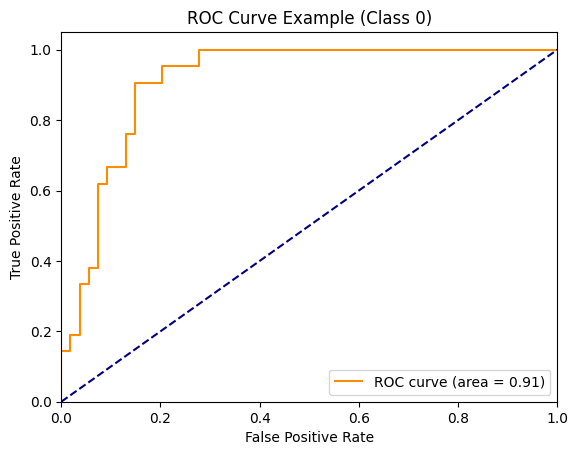

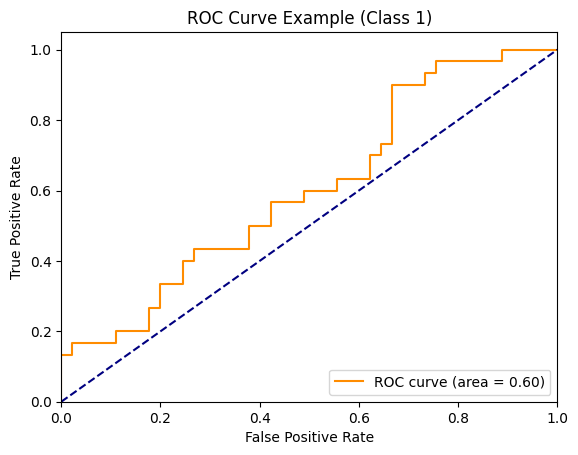

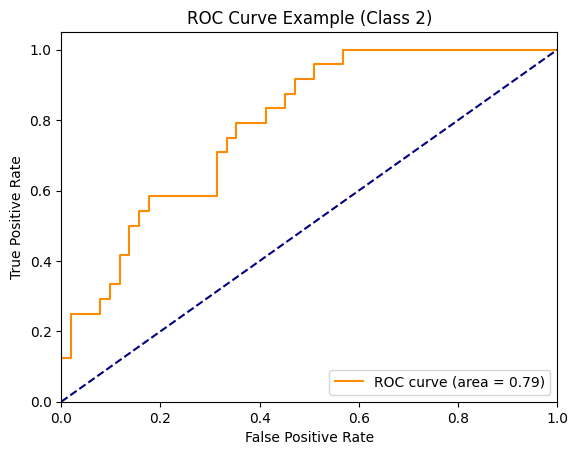

ROC-AUC score: 0.7677222740948232


In [74]:
# 붓꽃(Iris) 데이터셋을 이용하여 ROC 곡선을 확인하는 예제
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm, datasets
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Iris 데이터셋 로드
dataset = datasets.load_iris()
X_data = dataset.data
y_data = dataset.target

# 클래스별로 이진화 (One-vs-Rest 방식)
y_data = label_binarize(y_data, classes=[0, 1, 2])
n_classes = y_data.shape[1]

# 문제를 조금 더 어렵게 만들기 위해 노이즈 특성 추가
random_state = np.random.RandomState(0)
n_samples, n_features = X_data.shape
X_data = np.c_[X_data, random_state.randn(n_samples, 200 * n_features)]

print(X_data.shape)  # (150, 804)
print(y_data.shape)  # (150, 3)

# 학습 데이터와 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.5, random_state=0
)

# One-vs-Rest 방식의 SVM 분류 모델 생성
model = OneVsRestClassifier(
    svm.SVC(kernel='linear', probability=True, random_state=random_state)
)

# 모델 학습
model.fit(X_train, y_train)

# 각 클래스에 대해 ROC 곡선과 AUC 계산
y_score = model.decision_function(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(y_test[:, i], y_score[:, i])

# ROC 곡선 시각화
for class_i in range(n_classes):
    plt.plot(
        fpr[class_i],
        tpr[class_i],
        color='darkorange',
        label='ROC curve (area = {:0.2f})'.format(roc_auc[class_i])
    )

    # 랜덤 분류 기준선
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Example (Class %d)' % class_i)

    plt.legend(loc="lower right")
    plt.show()

# 전체 ROC-AUC 계산
print("ROC-AUC score:", roc_auc_score(y_test, y_score, multi_class='ovr'))

# SVM (Support Vector Machine)


SVM(Support Vector Machine)은 분류/회귀에 모두 사용할 수 있는 지도학습(Supervised learning) 알고리즘이다.

핵심 아이디어는 데이터를 가장 잘 분리하는 결정경계(Decision boundary)를 찾고, 그 경계와 가장 가까운 데이터(서포트 벡터, Support vectors)와의 **마진(Margin)** 을 최대화하는 것이다.

- 목적: 마진 최대화
- 장점: 고차원 데이터에서도 강력한 성능, 일반화 성능 우수
- 비선형 데이터: 커널 트릭(Kernel trick)으로 처리 가능


**Notation**  
$$\mathrm {분류기(Classifier) :}\; h_{w, b}(x) = g(w^Tx + b) $$

- $\mathrm y \in {-1, 1} $
- $g(z)=1$   if $z\ge0$, and $g(z) = -1$ otherwise


### Functional margin (예측의 확신 정도)

   


예측값과 결정경계(Decision boundary) 사이의 거리

<div align="center">
<img src="https://image2url.com/r2/default/images/1772682806183-7f669ffa-9efe-4a64-b83d-7ef723d79cab.png" width="400"/>
</div>

$$h_	heta(x)=g(	heta^Tx)$$

$	heta^Tx\ge 0$이면 양성(1), 아니면 음성(0)으로 분류한다.


**Functional margin of hyperplane**
$$\mathrm \; \hat{\gamma}^{(i)}(x) = y^{(i)}(w^Tx^{(i)} + b) $$
  
만약 confident한 prediction을 하고 싶다면 $y^{(i)}$=1이라면 functional margin이 커지기 위해서는 $(w^Tx^{(i)} + b) $값이 큰 양의 값이어야 한다. 반대로 음이라면 큰 음의 값을 갖도록 해야한다.

- 특징 :  
우리는 데이터가 선형 분류가 가능하다고 가정하면, w, b를 multiply해서 functional margin을 올릴 수 있다.
또한 우리는 $\hat{\gamma}$을 각 학습 데이터들의 마진들중 최솟값으로 선택한다.  
$$ \hat{\gamma} = \underset{i=1, 2, ...n}{min \hat{\gamma}^{(i)}} $$


### 2. Geometric margin


가장 가까운 datapoint와 decision boundary 사이의 거리를 의미한다. 
위의 사진1을 참고하면
점 B(support vector)는 다음과 같이 작성 가능하다.  
$$ x^{(i)} - {\gamma}^{(i)} \frac{w}{\parallel w \parallel} $$
  
     
또한 결정 경계에서 y값은 0이되므로 일반화된 식으로 표현하면 다음과 같다.
$$   {\gamma}^{(i)} =  y^{(i)}(\frac{w^Tx^{(i)} + b}{\parallel w \parallel}) =   y^{(i)}({(\frac {w} {\parallel w \parallel})^Tx^{(i)} + \frac {b}{\parallel w \parallel}}) $$

우리는 geometric margin을 최대화할 수 있는 w, b를 찾고자 다음과 같이 계산한다.
$$ min_{w,b}\frac{1}{2}||{w}||^2$$
 $$y^{(i)}(w^Tx^{(i)} + b) \ge 1, i=1,...,n$$

위의 값을 최소화 하는 방식은 나중에 optimal margin classifier가 high dimensional space에서도 효율적으로 작동할 수 있게 해주는 kernel을 사용하도록 허용해준다는 장점이 있다.



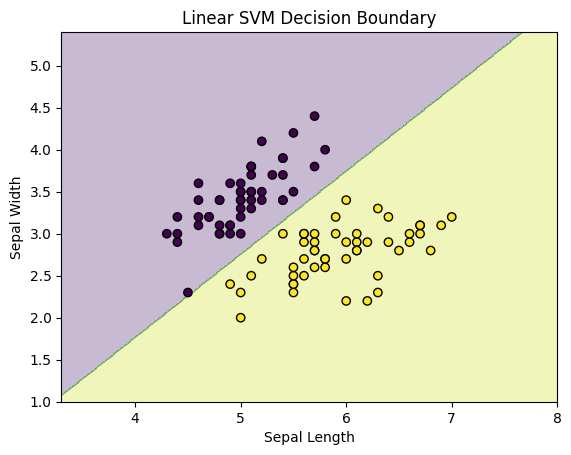

In [79]:
# 붓꽃(Iris) 데이터셋을 이용한 SVM 분류 예제
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# Iris 데이터 로드
iris = datasets.load_iris()

# 클래스 2개만 사용 (setosa vs versicolor)
X = iris.data[:100, :2]   # feature 2개만 사용
y = iris.target[:100]

# Linear SVM 모델
model = SVC(kernel='linear')
model.fit(X, y)

# 그래프 범위 설정
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# 결정경계 계산
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 배경 영역
plt.contourf(xx, yy, Z, alpha=0.3)

# 데이터 포인트
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Linear SVM Decision Boundary")

plt.show()